In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, mean_absolute_error, classification_report
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import os
import time
from datetime import timedelta
import sys
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [3]:
class CEFRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx]) - 1

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [4]:
df = pd.read_csv('ru_cefr_short.csv')
df['label'] = df['textbook-assigned cefr level'].astype(int)
df

,fragment,textbook-assigned cefr level,label
0,"Весной, летом и осенью почти каждую субботу он...",1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1
2,На каждой двери красные плакаты и красные фона...,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1
...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6
7320,Mapillary использует программное обеспечение д...,6,6


In [5]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Размер обучающей выборки без аугментаций: {len(train_texts)}")
print(f"Размер валидационной выборки без аугментаций: {len(val_texts)}")

Размер обучающей выборки без аугментаций: 5857
Размер валидационной выборки без аугментаций: 1465


In [10]:
def fit(c2):
    model_name = 'sberbank-ai/ruBert-large'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=6,
        id2label={0: 'A1', 1: 'A2', 2: 'B1', 3: 'B2', 4: 'C1', 5: 'C2'},
        label2id={'A1': 0, 'A2': 1, 'B1': 2, 'B2': 3, 'C1': 4, 'C2': 5}
    )
    
    model = model.to(device)
    print(f"Модель инициализирована")

    
    train_labels_aug = train_labels.tolist() + [6]*len(c2)
    train_texts_aug = train_texts.tolist() + c2['generated-text'].tolist()
    
    train_dataset = CEFRDataset(train_texts_aug, train_labels_aug, tokenizer)
    val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)
    
    print(f"Обучающая выборка с аугментациями: {len(train_texts_aug)}")
    print(f"Валидационная выборка без аугментации: {len(val_texts)}")

    training_args = TrainingArguments(
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        warmup_steps=100,
        weight_decay=0.01,
        logging_steps=100,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        greater_is_better=False,
        learning_rate=2e-5
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
    )

    train_start_time = time.time()
    trainer.train()
    train_time = time.time() - train_start_time
    print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

    return model, val_dataset, train_time
    

In [11]:
def predict(model, val_dataset, device, train_time):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for i in range(len(val_dataset)):
            batch = val_dataset[i]
            
            inputs = {
                'input_ids': batch['input_ids'].unsqueeze(0).to(device),
                'attention_mask': batch['attention_mask'].unsqueeze(0).to(device)
            }
            
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            predictions.append(pred + 1)  
            true_labels.append(batch['labels'].item() + 1)  

    accuracy = accuracy_score(true_labels, predictions)
    f1_micro = f1_score(true_labels, predictions, average="micro")
    f1_macro = f1_score(true_labels, predictions, average="macro")
    f1_weighted = f1_score(true_labels, predictions, average="weighted")
    mae = mean_absolute_error(true_labels, predictions)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Micro: {f1_micro:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print(f"MAE: {mae:.4f}")
    print(classification_report(true_labels, predictions))

    print(f"\n\n{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")
    
    return true_labels, predictions

In [12]:
def visualize_cm(true_labels, predictions):
    cm = confusion_matrix(true_labels, predictions)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    
    for i in range(6):
        for j in range(6):
            ax.text(j, i, cm[i, j], ha='center', va='center')
    
    plt.xlabel('Предсказанные')
    plt.ylabel('Истинные')
    plt.title('Матрица ошибок')
    plt.colorbar(im)
    plt.show()
    

# Температура 0.0

In [13]:
c2 = pd.read_csv('c2_generated_llama3_temp_0_0.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.025100,0.968839
2,0.579300,1.014021
3,0.173600,1.479820


Обучение завершено за 322.63 секунд (0:05:22)


In [14]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6082
F1 Micro: 0.6082
F1 Macro: 0.5408
F1 Weighted: 0.5999
MAE: 0.4717
              precision    recall  f1-score   support

           1       0.91      0.38      0.53       153
           2       0.51      0.74      0.60       227
           3       0.61      0.74      0.67       475
           4       0.63      0.50      0.56       343
           5       0.64      0.57      0.60       237
           6       0.83      0.17      0.28        30

    accuracy                           0.61      1465
   macro avg       0.69      0.52      0.54      1465
weighted avg       0.64      0.61      0.60      1465



0.6082
0.6082
0.5408
0.5999
0.4717
322.63


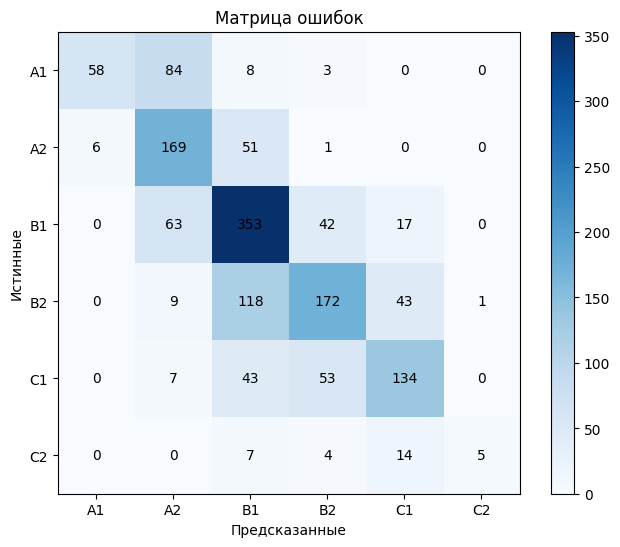

In [15]:
visualize_cm(true_labels, predictions)

# Температура 0.1

In [16]:
c2 = pd.read_csv('c2_generated_llama3_temp_0_1.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.026100,0.961903
2,0.527900,1.049939
3,0.135500,1.440352


Обучение завершено за 328.35 секунд (0:05:28)


In [17]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6143
F1 Micro: 0.6143
F1 Macro: 0.5363
F1 Weighted: 0.6082
MAE: 0.4594
              precision    recall  f1-score   support

           1       0.91      0.42      0.57       153
           2       0.51      0.77      0.62       227
           3       0.62      0.69      0.66       475
           4       0.62      0.57      0.60       343
           5       0.65      0.56      0.60       237
           6       0.75      0.10      0.18        30

    accuracy                           0.61      1465
   macro avg       0.68      0.52      0.54      1465
weighted avg       0.64      0.61      0.61      1465



0.6143
0.6143
0.5363
0.6082
0.4594
328.35


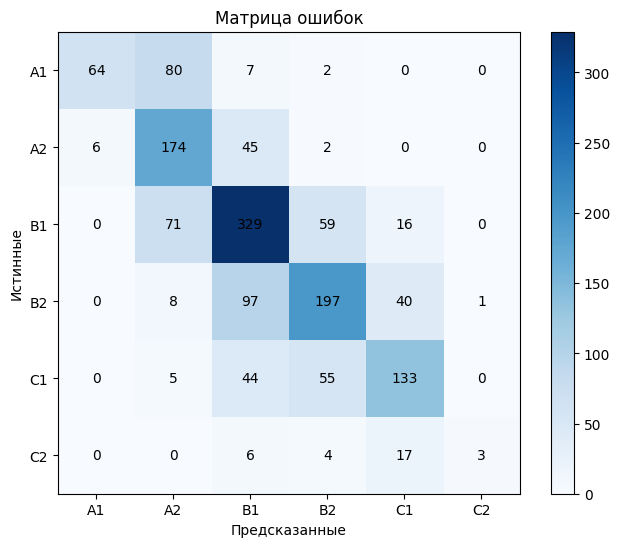

In [18]:
visualize_cm(true_labels, predictions)

# Температура 0.2

In [19]:
c2 = pd.read_csv('c2_generated_llama3_temp_0_2.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.020900,0.967096
2,0.539900,1.038925
3,0.134900,1.414345


Обучение завершено за 327.61 секунд (0:05:27)


In [20]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6239
F1 Micro: 0.6239
F1 Macro: 0.5296
F1 Weighted: 0.6170
MAE: 0.4478
              precision    recall  f1-score   support

           1       0.92      0.46      0.62       153
           2       0.53      0.75      0.62       227
           3       0.62      0.72      0.66       475
           4       0.64      0.56      0.60       343
           5       0.65      0.59      0.62       237
           6       0.33      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.62      0.52      0.53      1465
weighted avg       0.64      0.62      0.62      1465



0.6239
0.6239
0.5296
0.6170
0.4478
327.61


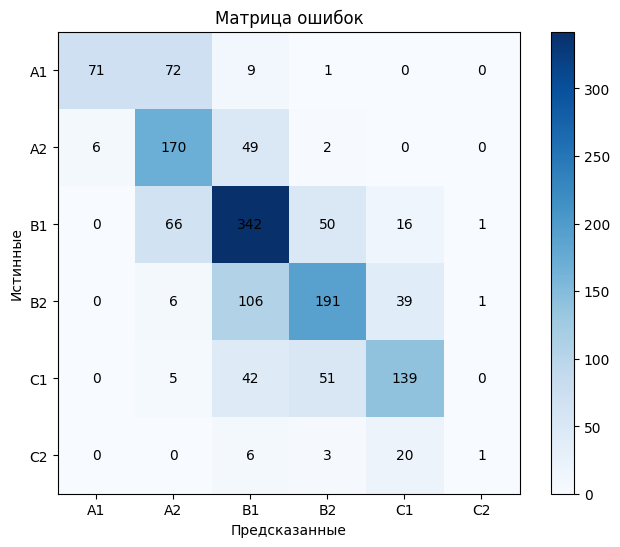

In [21]:
visualize_cm(true_labels, predictions)

# Температура 0.4

In [22]:
c2 = pd.read_csv('c2_generated_llama3_temp_0_4.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.028700,0.957067
2,0.541100,1.014478
3,0.146600,1.424143


Обучение завершено за 328.01 секунд (0:05:28)


In [23]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6123
F1 Micro: 0.6123
F1 Macro: 0.5168
F1 Weighted: 0.6047
MAE: 0.4608
              precision    recall  f1-score   support

           1       0.91      0.41      0.57       153
           2       0.52      0.75      0.62       227
           3       0.63      0.68      0.65       475
           4       0.61      0.57      0.59       343
           5       0.62      0.60      0.61       237
           6       1.00      0.03      0.06        30

    accuracy                           0.61      1465
   macro avg       0.72      0.51      0.52      1465
weighted avg       0.64      0.61      0.60      1465



0.6123
0.6123
0.5168
0.6047
0.4608
328.01


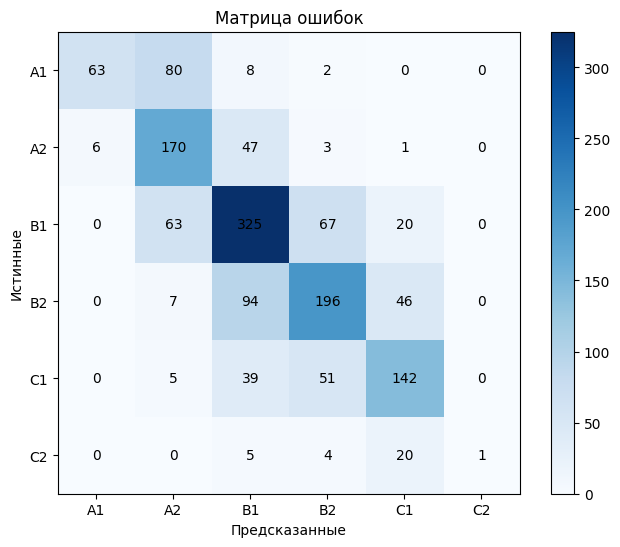

In [24]:
visualize_cm(true_labels, predictions)

# Температура 0.5

In [25]:
c2 = pd.read_csv('c2_generated_llama3_temp_0_5.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.024700,0.940588
2,0.542400,1.042310
3,0.135100,1.419929


Обучение завершено за 327.99 секунд (0:05:27)


In [26]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6212
F1 Micro: 0.6212
F1 Macro: 0.5297
F1 Weighted: 0.6160
MAE: 0.4505
              precision    recall  f1-score   support

           1       0.90      0.48      0.62       153
           2       0.54      0.70      0.61       227
           3       0.64      0.67      0.66       475
           4       0.60      0.62      0.61       343
           5       0.63      0.61      0.62       237
           6       0.50      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.63      0.52      0.53      1465
weighted avg       0.64      0.62      0.62      1465



0.6212
0.6212
0.5297
0.6160
0.4505
327.99


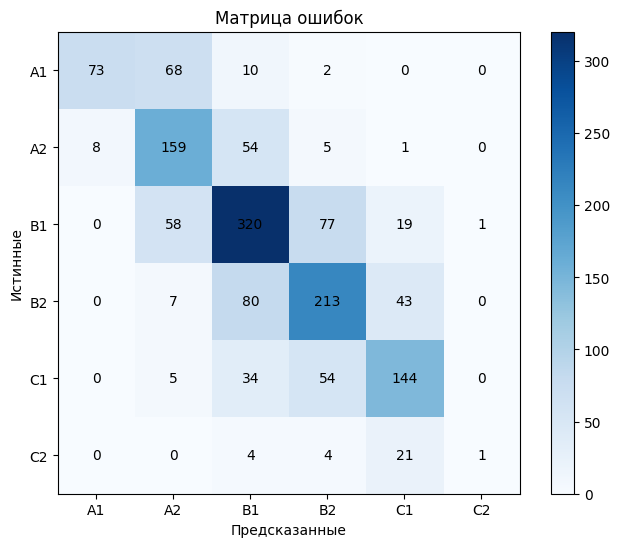

In [27]:
visualize_cm(true_labels, predictions)

# Температура 0.6

In [28]:
c2 = pd.read_csv('c2_generated_llama3_temp_0_6.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.027700,0.959990
2,0.539500,1.038872
3,0.131900,1.401615


Обучение завершено за 328.27 секунд (0:05:28)


In [29]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6150
F1 Micro: 0.6150
F1 Macro: 0.5281
F1 Weighted: 0.6080
MAE: 0.4546
              precision    recall  f1-score   support

           1       0.91      0.41      0.57       153
           2       0.52      0.76      0.62       227
           3       0.62      0.69      0.65       475
           4       0.62      0.59      0.60       343
           5       0.65      0.57      0.60       237
           6       1.00      0.07      0.12        30

    accuracy                           0.62      1465
   macro avg       0.72      0.51      0.53      1465
weighted avg       0.65      0.62      0.61      1465



0.6150
0.6150
0.5281
0.6080
0.4546
328.27


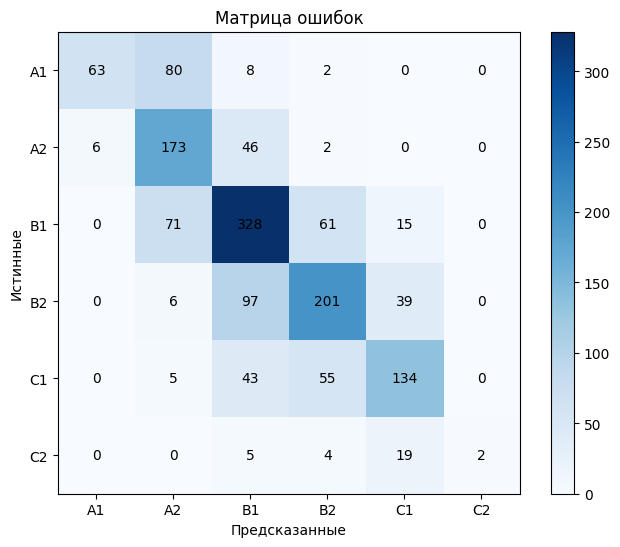

In [30]:
visualize_cm(true_labels, predictions)

# Температура 0.7

In [31]:
c2 = pd.read_csv('c2_generated_llama3_temp_0_7.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.027200,0.948447
2,0.542300,1.033372
3,0.136200,1.411770


Обучение завершено за 328.07 секунд (0:05:28)


In [32]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6218
F1 Micro: 0.6218
F1 Macro: 0.5279
F1 Weighted: 0.6149
MAE: 0.4471
              precision    recall  f1-score   support

           1       0.91      0.46      0.61       153
           2       0.53      0.76      0.63       227
           3       0.63      0.69      0.66       475
           4       0.62      0.58      0.60       343
           5       0.63      0.59      0.61       237
           6       1.00      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.72      0.52      0.53      1465
weighted avg       0.65      0.62      0.61      1465



0.6218
0.6218
0.5279
0.6149
0.4471
328.07


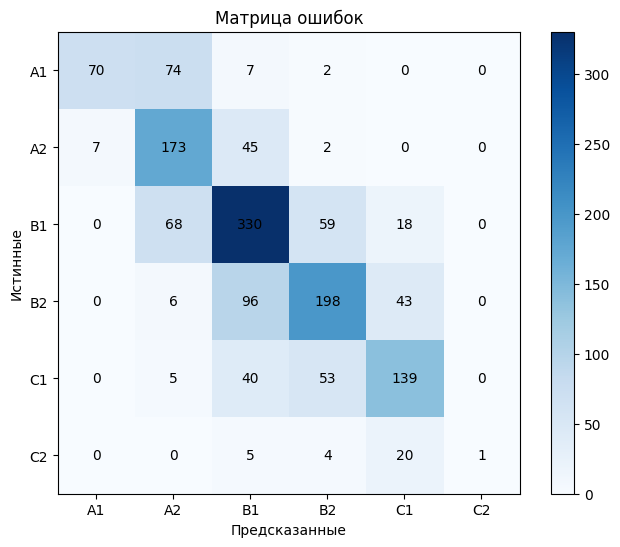

In [33]:
visualize_cm(true_labels, predictions)

# Температура 0.8

In [34]:
c2 = pd.read_csv('c2_generated_llama3_temp_0_8.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.021900,0.979164
2,0.551800,1.034888
3,0.138800,1.429212


Обучение завершено за 327.94 секунд (0:05:27)


In [35]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6068
F1 Micro: 0.6068
F1 Macro: 0.5195
F1 Weighted: 0.5996
MAE: 0.4662
              precision    recall  f1-score   support

           1       0.94      0.40      0.56       153
           2       0.52      0.73      0.60       227
           3       0.61      0.71      0.65       475
           4       0.61      0.54      0.57       343
           5       0.63      0.59      0.61       237
           6       0.40      0.07      0.11        30

    accuracy                           0.61      1465
   macro avg       0.62      0.51      0.52      1465
weighted avg       0.63      0.61      0.60      1465



0.6068
0.6068
0.5195
0.5996
0.4662
327.94


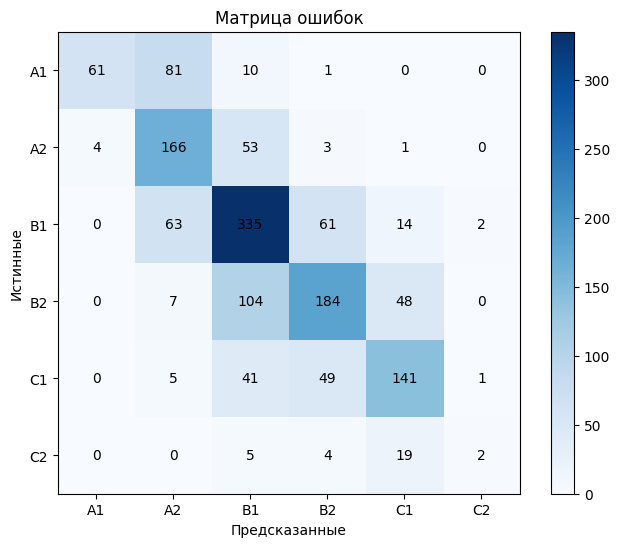

In [36]:
visualize_cm(true_labels, predictions)

# Температура 0.9

In [37]:
c2 = pd.read_csv('c2_generated_llama3_temp_0_9.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.028100,0.955459
2,0.534700,1.019076
3,0.139200,1.421583


Обучение завершено за 328.04 секунд (0:05:28)


In [38]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6143
F1 Micro: 0.6143
F1 Macro: 0.5294
F1 Weighted: 0.6088
MAE: 0.4601
              precision    recall  f1-score   support

           1       0.92      0.50      0.65       153
           2       0.52      0.78      0.63       227
           3       0.61      0.66      0.63       475
           4       0.61      0.56      0.59       343
           5       0.65      0.59      0.62       237
           6       1.00      0.03      0.06        30

    accuracy                           0.61      1465
   macro avg       0.72      0.52      0.53      1465
weighted avg       0.64      0.61      0.61      1465



0.6143
0.6143
0.5294
0.6088
0.4601
328.04


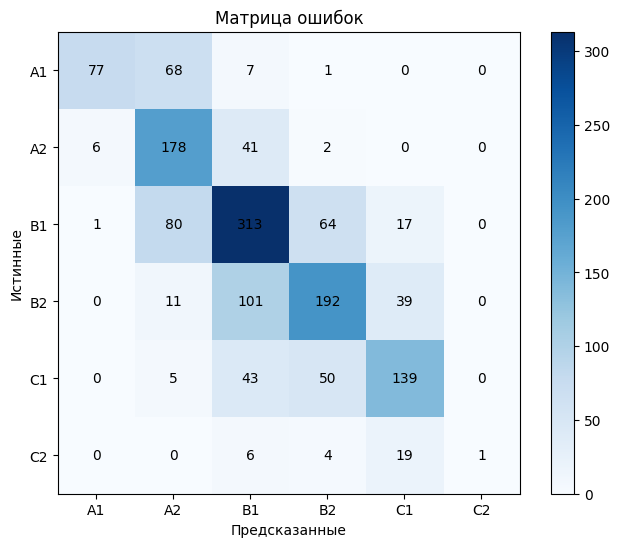

In [39]:
visualize_cm(true_labels, predictions)

# Температура 1.0

In [40]:
c2 = pd.read_csv('c2_generated_llama3_temp_1_0.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.027100,0.955974
2,0.540300,1.065205
3,0.142400,1.440589


Обучение завершено за 327.95 секунд (0:05:27)


In [41]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6225
F1 Micro: 0.6225
F1 Macro: 0.5386
F1 Weighted: 0.6169
MAE: 0.4512
              precision    recall  f1-score   support

           1       0.91      0.47      0.62       153
           2       0.53      0.76      0.62       227
           3       0.63      0.70      0.66       475
           4       0.62      0.58      0.60       343
           5       0.65      0.57      0.60       237
           6       0.67      0.07      0.12        30

    accuracy                           0.62      1465
   macro avg       0.67      0.52      0.54      1465
weighted avg       0.64      0.62      0.62      1465



0.6225
0.6225
0.5386
0.6169
0.4512
327.95


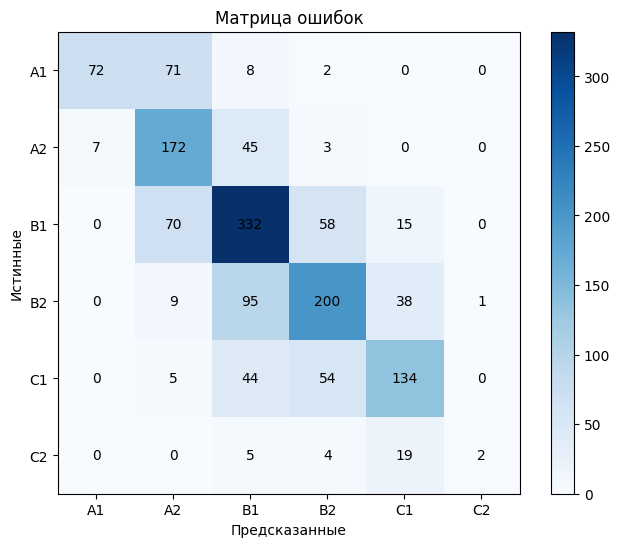

In [42]:
visualize_cm(true_labels, predictions)

# Температура 1.1

In [43]:
c2 = pd.read_csv('c2_generated_llama3_temp_1_1.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.024900,0.948783
2,0.538100,1.031500
3,0.138000,1.451518


Обучение завершено за 328.21 секунд (0:05:28)


In [44]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6232
F1 Micro: 0.6232
F1 Macro: 0.5345
F1 Weighted: 0.6176
MAE: 0.4498
              precision    recall  f1-score   support

           1       0.92      0.52      0.66       153
           2       0.54      0.74      0.62       227
           3       0.63      0.69      0.66       475
           4       0.62      0.58      0.60       343
           5       0.63      0.58      0.60       237
           6       1.00      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.72      0.52      0.53      1465
weighted avg       0.65      0.62      0.62      1465



0.6232
0.6232
0.5345
0.6176
0.4498
328.21


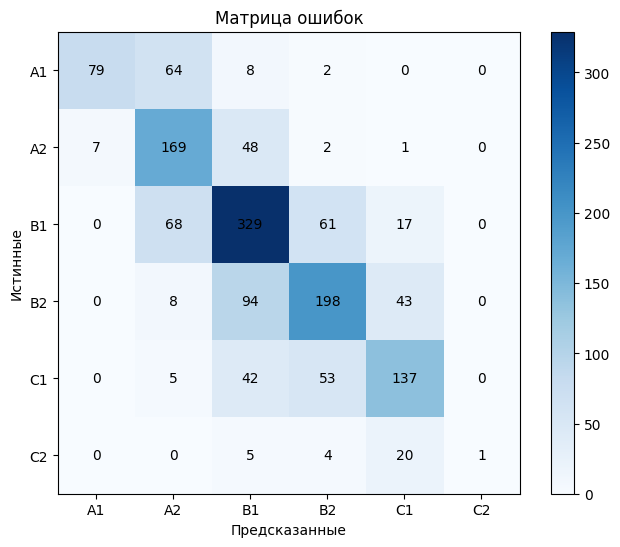

In [45]:
visualize_cm(true_labels, predictions)

# Температура 1.2

In [46]:
c2 = pd.read_csv('c2_generated_llama3_temp_1_2.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.019000,0.956848
2,0.530900,1.031417
3,0.138700,1.430583


Обучение завершено за 328.24 секунд (0:05:28)


In [47]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6239
F1 Micro: 0.6239
F1 Macro: 0.5319
F1 Weighted: 0.6177
MAE: 0.4471
              precision    recall  f1-score   support

           1       0.89      0.48      0.63       153
           2       0.53      0.76      0.62       227
           3       0.63      0.69      0.66       475
           4       0.62      0.58      0.60       343
           5       0.65      0.59      0.62       237
           6       1.00      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.72      0.52      0.53      1465
weighted avg       0.65      0.62      0.62      1465



0.6239
0.6239
0.5319
0.6177
0.4471
328.24


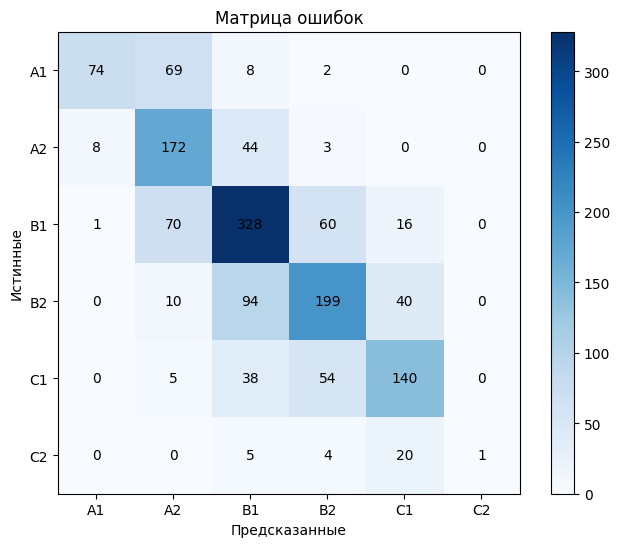

In [48]:
visualize_cm(true_labels, predictions)

# Температура 1.3

In [49]:
c2 = pd.read_csv('c2_generated_llama3_temp_1_3.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.029700,0.956926
2,0.524000,1.077060
3,0.128400,1.469084


Обучение завершено за 328.07 секунд (0:05:28)


In [50]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6164
F1 Micro: 0.6164
F1 Macro: 0.5234
F1 Weighted: 0.6091
MAE: 0.4594
              precision    recall  f1-score   support

           1       0.91      0.46      0.61       153
           2       0.51      0.78      0.62       227
           3       0.62      0.71      0.66       475
           4       0.64      0.55      0.59       343
           5       0.63      0.56      0.60       237
           6       1.00      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.72      0.51      0.52      1465
weighted avg       0.65      0.62      0.61      1465



0.6164
0.6164
0.5234
0.6091
0.4594
328.07


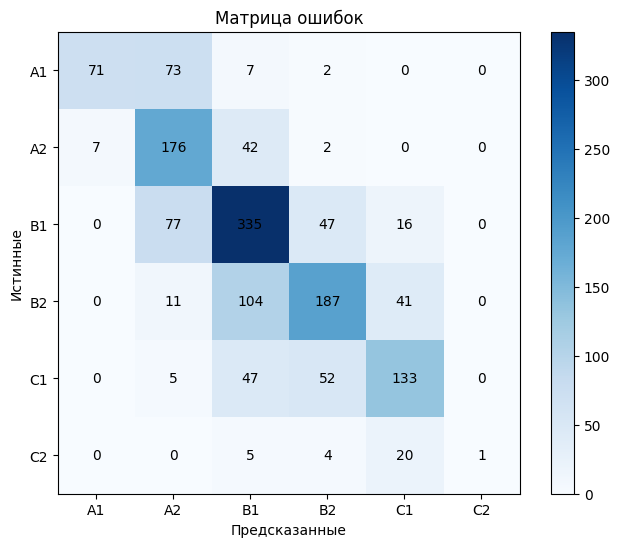

In [51]:
visualize_cm(true_labels, predictions)

# Температура 1.4

In [52]:
c2 = pd.read_csv('c2_generated_llama3_temp_1_4.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.025400,0.958086
2,0.530300,1.042583
3,0.134400,1.425744


Обучение завершено за 328.09 секунд (0:05:28)


In [53]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6177
F1 Micro: 0.6177
F1 Macro: 0.5221
F1 Weighted: 0.6095
MAE: 0.4546
              precision    recall  f1-score   support

           1       0.92      0.42      0.58       153
           2       0.52      0.77      0.62       227
           3       0.61      0.71      0.66       475
           4       0.63      0.55      0.59       343
           5       0.65      0.59      0.62       237
           6       1.00      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.72      0.51      0.52      1465
weighted avg       0.65      0.62      0.61      1465



0.6177
0.6177
0.5221
0.6095
0.4546
328.09


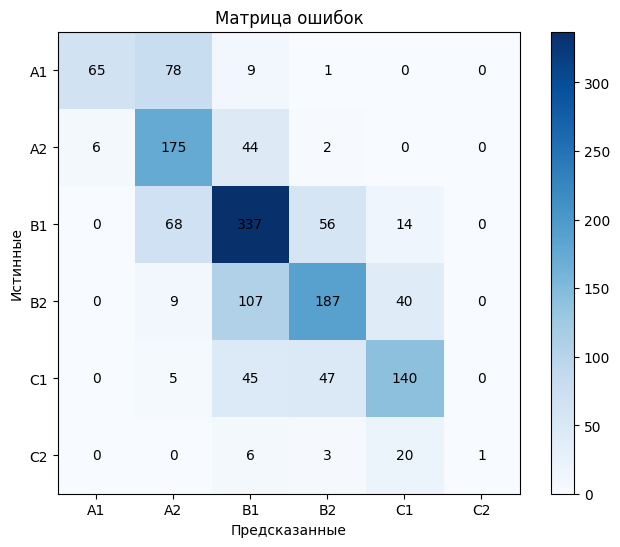

In [54]:
visualize_cm(true_labels, predictions)

# Температура 1.5

In [55]:
c2 = pd.read_csv('c2_generated_llama3_temp_1_5.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.026300,0.963497
2,0.537700,1.041922
3,0.141800,1.441548


Обучение завершено за 328.23 секунд (0:05:28)


In [56]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6137
F1 Micro: 0.6137
F1 Macro: 0.5201
F1 Weighted: 0.6074
MAE: 0.4601
              precision    recall  f1-score   support

           1       0.92      0.43      0.59       153
           2       0.52      0.77      0.62       227
           3       0.63      0.68      0.65       475
           4       0.61      0.57      0.59       343
           5       0.65      0.59      0.62       237
           6       0.20      0.03      0.06        30

    accuracy                           0.61      1465
   macro avg       0.59      0.51      0.52      1465
weighted avg       0.63      0.61      0.61      1465



0.6137
0.6137
0.5201
0.6074
0.4601
328.23


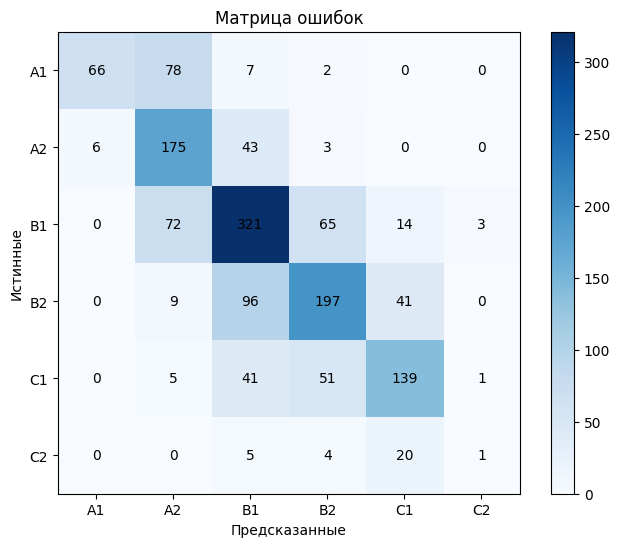

In [57]:
visualize_cm(true_labels, predictions)